In [54]:
import pandas as pd
import geopandas as gpd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [55]:
# Cargar dataset

df = pd.read_parquet("../data/grid_ocean/NOAA_encology.parquet")
df.head()

,mp_id,lat,lon,microplastics_measurement,unit,concentration_class_range,mesh_size_mm,distance_to_coast_km,temperature,salinity,chlorophyll,nitrate,phosphate,oxygen_dissolved,oxygen_utilization,profile_eco,dist_deg
0,0,45.28,-60.29,0.000000,pieces/m3,0-0.0005,0.335,60.127269,6.299999,32.785152,0.509678,5.787156,0.834564,265.093384,57.033932,cold_shelf,0.350000
1,1,40.93,-70.65,0.002276,pieces/m3,0.0005-0.005,0.335,39.954054,12.127690,34.283134,0.336776,5.251710,0.567093,248.744659,25.638559,cold_shelf,0.165529
2,2,40.93,-70.65,0.004320,pieces/m3,0.0005-0.005,0.335,39.954054,12.127690,34.283134,0.336776,5.251710,0.567093,248.744659,25.638559,cold_shelf,0.165529
3,3,40.30,-69.77,0.000000,pieces/m3,0-0.0005,0.335,82.057580,12.127690,34.283134,0.494065,5.251710,0.567093,248.744659,25.638559,cold_shelf,0.304795
4,4,39.88,-67.15,0.000000,pieces/m3,0-0.0005,0.335,357.363239,8.405213,35.200493,0.848809,14.126949,0.930865,236.792160,56.462185,open_sea_temperate,0.192094


## Modelo de clasificación

In [56]:
# Convertir medición de microplásticos a categórica basada en rangos

bins = [0, 1, df['microplastics_measurement'].max()]  # ajusta según describe()
labels = ['low', 'high']

# Crear nueva columna con rangos
df['concentration_class_range'] = pd.cut(
    df['microplastics_measurement'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Revisar la distribución por rango
df['concentration_class_range'].value_counts()

concentration_class_range
low     11722
high     2433
Name: count, dtype: int64

In [57]:
features = ['distance_to_coast_km', 'temperature', 'salinity', 'chlorophyll', 'nitrate',
            'phosphate', 'oxygen_dissolved', 'oxygen_utilization']
target = 'concentration_class_range'  
X = df[features]
y = df[target]

In [58]:
# Dividir datos en entrenamiento y prueba 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrenar modelo de clasificación
model = RandomForestClassifier(n_estimators=200,
                               class_weight='balanced',
                               random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [59]:
# Evaluar el modelo
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        high       0.66      0.83      0.74       489
         low       0.96      0.91      0.94      2342

    accuracy                           0.90      2831
   macro avg       0.81      0.87      0.84      2831
weighted avg       0.91      0.90      0.90      2831



In [60]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_pred)


array([[ 407,   82],
       [ 211, 2131]])

In [61]:
# Ajustar umbral de clasificación 
y_proba = model.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= 0.6).astype(int)

In [62]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test, y_proba)

0.9365647140594356

## Modelo de Regresión

In [63]:
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [64]:
# Fijar variable objetivo
y = df['microplastics_measurement']
y.describe()

count     14155.000000
mean        504.973226
std        9254.932732
min           0.000000
25%           0.002000
50%           0.017280
75%           0.312500
max      800000.000000
Name: microplastics_measurement, dtype: float64

- muchos ceros
- cola larga
- valores extremos

luego probaremos log1p, pero primero baseline crudo

In [65]:
# Fijar variables predictoras
features = ['distance_to_coast_km', 'temperature', 'salinity', 'chlorophyll', 'nitrate',
            'phosphate', 'oxygen_dissolved', 'oxygen_utilization']
target = 'concentration_class_range'  
X = df[features]



In [66]:
# Eliminar filas con valores faltantes (si hubiera)
mask = X.notna().all(axis=1) & y.notna()
X = X[mask]
y = y[mask]


In [67]:
# Dividir datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


In [68]:
# Entrenar modelo de regresión lineal con escalado
lin_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

lin_model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None


In [69]:
# Hacer predicciones y evaluar el modelo
y_pred = lin_model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R²:", r2_score(y_test, y_pred))


MAE: 1072.282304418571
RMSE: 5311.237102756668
R²: 0.03096414909943368


MODELO 2

In [70]:
ridge_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)

y_pred = ridge_model.predict(X_test)

print("Ridge R²:", r2_score(y_test, y_pred))


Ridge R²: 0.030970482358640417


MODELO 3

In [71]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [72]:
y_pred = rf_model.predict(X_test)

print("RF MAE:", mean_absolute_error(y_test, y_pred))
print("RF RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("RF R²:", r2_score(y_test, y_pred))


RF MAE: 661.9636104744028
RF RMSE: 7039.174756293265
RF R²: -0.7021269976926838


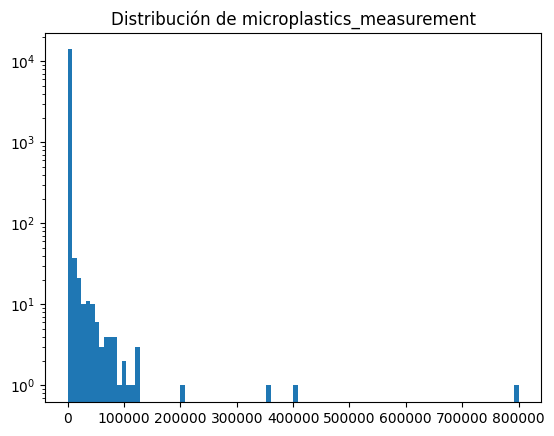

In [73]:
import matplotlib.pyplot as plt

plt.hist(y, bins=100)
plt.yscale('log')
plt.title("Distribución de microplastics_measurement")
plt.show()


- una cola larguísima
- masa en 0–100 y algunos valores muy grandes

Escala logaritmica de target

In [74]:
y_log = np.log1p(y)


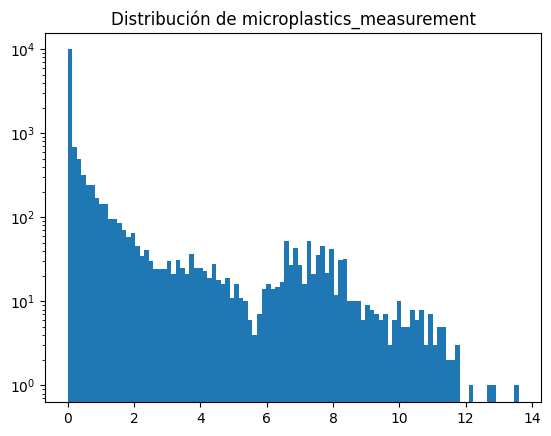

In [75]:
plt.hist(y_log, bins=100)
plt.yscale('log')
plt.title("Distribución de microplastics_measurement")
plt.show()


In [76]:
X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log,
    test_size=0.2,
    random_state=42
)


Linear Regression

In [77]:
lin_model_log = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

lin_model_log.fit(X_train, y_train_log)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None


In [78]:
y_pred_log = lin_model_log.predict(X_test)

print("MAE:", mean_absolute_error(y_test_log, y_pred_log))
print("RMSE:", np.sqrt(mean_squared_error(y_test_log, y_pred_log)))
print("R²:", r2_score(y_test_log, y_pred_log))

MAE: 0.9511372545722468
RMSE: 1.6825163216834806
R²: 0.1281846998251469


Ridge

In [79]:
ridge_model_log = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=1.0))
])

ridge_model_log.fit(X_train, y_train_log)

y_pred_log = ridge_model_log.predict(X_test)

print("Ridge R²:", r2_score(y_test_log, y_pred_log))

Ridge R²: 0.1283900234746771


Random forest

In [80]:
rf_model_log = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1
)

rf_model_log.fit(X_train, y_train_log)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",20
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples

In [81]:
y_pred_log = rf_model_log.predict(X_test)

print("RF MAE:", mean_absolute_error(y_test_log, y_pred_log))
print("RF RMSE:", np.sqrt(mean_squared_error(y_test_log, y_pred_log)))
print("RF R²:", r2_score(y_test_log, y_pred_log))

RF MAE: 0.5154814925785189
RF RMSE: 1.1055704731672031
RF R²: 0.6235747240894935


In [82]:
mp_pred = np.expm1(y_pred_log)
mp_pred

array([0.1471927 , 3.05522393, 0.82858726, ..., 0.21507666, 0.41091278,
       0.2139364 ], shape=(2831,))

Tras una transformación logarítmica del target y la regularización del modelo, la concentración de microplásticos muestra una relación consistente y no lineal con variables ambientales, explicando aproximadamente el 63% de la variabilidad observada. Esto sugiere que los gradientes ambientales capturan una fracción sustancial de la presión por microplásticos, aunque persiste variabilidad asociada a procesos locales no observados

## Eco-profile cross validation

Aunque el modelo no incluye predictores espaciales explícitos, la validación espacial sigue siendo necesaria porque tanto las variables ambientales como la respuesta presentan estructura espacial

In [83]:
gdf = gpd.read_file("../data/grid_ocean/gdf_microplastics_with_env.gpkg")
gdf = gdf.to_crs(3857)

In [84]:
from sklearn.model_selection import GroupKFold

X = gdf[features]
y = np.log1p(gdf["microplastics_measurement"])
groups = gdf["profile_eco"]

cv = GroupKFold(n_splits=gdf["profile_eco"].nunique())

for train_idx, test_idx in cv.split(X, y, groups):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    rf = RandomForestRegressor(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=20,
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)

    print(
        f"Profile test: {y_test.index.size} samples | "
        f"R² = {r2_score(y_test, y_pred):.2f}"
    )


Profile test: 5500 samples | R² = -0.11
Profile test: 4101 samples | R² = -2.28
Profile test: 2520 samples | R² = 0.07
Profile test: 1965 samples | R² = -0.22
Profile test: 69 samples | R² = -0.28


Eco-profile CV falla porque estamos pidiendo extrapolación entre procesos ecológicos distintos

In [85]:
block_size = 100_000  # 100 km

import numpy as np

gdf["x_block"] = (gdf.geometry.x // block_size).astype(int)
gdf["y_block"] = (gdf.geometry.y // block_size).astype(int)

gdf["spatial_block"] = (
    gdf["x_block"].astype(str) + "_" + gdf["y_block"].astype(str)
)


<Axes: >

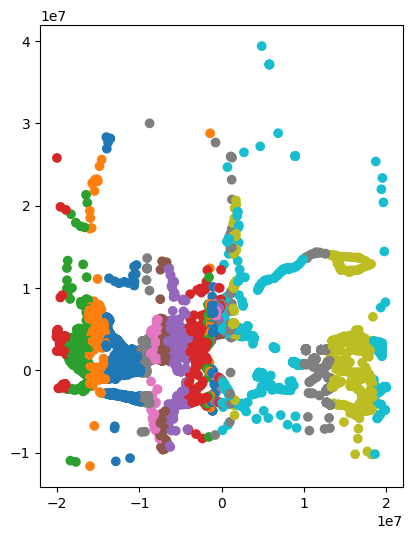

In [86]:
gdf.plot(
    column="spatial_block",
    categorical=True,
    legend=False,
    figsize=(8,6)
)


In [87]:
from sklearn.model_selection import GroupKFold
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
import numpy as np

features = ['distance_to_coast_km', 'temperature', 'salinity', 'chlorophyll', 'nitrate',
            'phosphate', 'oxygen_dissolved', 'oxygen_utilization']
X = gdf[features]
y = np.log1p(gdf["microplastics_measurement"])
groups = gdf["spatial_block"]

cv = GroupKFold(n_splits=5)

r2s, maes, rmses = [], [], []

for train_idx, test_idx in cv.split(X, y, groups):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    rf = RandomForestRegressor(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=20,
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)

    r2s.append(r2_score(y_test, y_pred))
    maes.append(mean_absolute_error(y_test, y_pred))
    rmses.append(np.sqrt(mean_squared_error(y_test, y_pred)))

print("Spatial CV R²:", np.mean(r2s))
print("Spatial CV MAE:", np.mean(maes))
print("Spatial CV RMSE:", np.mean(rmses))


Spatial CV R²: 0.22962475028122445
Spatial CV MAE: 0.6727270007973445
Spatial CV RMSE: 1.5453807869412262


Spatial blocks bajan el R² porque obligan al modelo a predecir en regiones completas nunca vistas

## Mapa contínuo

#### Entrenar el modelo final

In [88]:
from sklearn.ensemble import RandomForestRegressor

features = ['distance_to_coast_km', 'temperature', 'salinity', 'chlorophyll', 'nitrate',
            'phosphate', 'oxygen_dissolved', 'oxygen_utilization']
X = gdf[features]
y = np.log1p(gdf["microplastics_measurement"])

rf_final = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1
)

rf_final.fit(X, y)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",20
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples

#### Preparar grilla

In [89]:
import geopandas as gpd

grilla = gpd.read_file("../data/grid_ocean/grilla_agua.gpkg")


In [90]:
missing = set(features) - set(grilla.columns)
extra = set(grilla.columns) - set(features)

print("Faltan variables:", missing)
print("Variables extra:", extra)


Faltan variables: set()
Variables extra: {'lon', 'geometry', 'lat'}


In [91]:
X_grid = grilla[features]

### Predicción sobre la grilla

In [92]:
grilla["microplastics_log_est"] = rf_final.predict(X_grid)
grilla["microplastics_est"] = np.expm1(grilla["microplastics_log_est"])


In [93]:
grilla["microplastics_log_est"].describe(), np.log1p(gdf["microplastics_measurement"]).describe()


(count    127013.000000
 mean          0.422910
 std           0.604704
 min           0.004300
 25%           0.195018
 50%           0.285146
 75%           0.441371
 max          10.076415
 Name: microplastics_log_est, dtype: float64,
 count    14155.000000
 mean         0.693182
 std          1.835155
 min          0.000000
 25%          0.001998
 50%          0.017132
 75%          0.271934
 max         13.592368
 Name: microplastics_measurement, dtype: float64)

<Axes: >

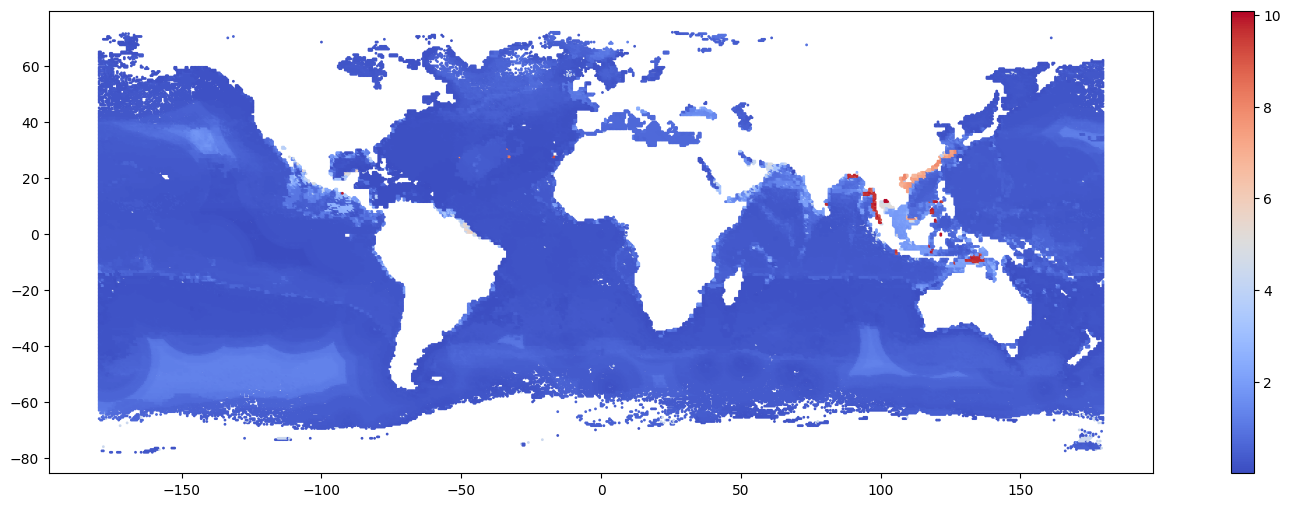

In [94]:
grilla.plot(
    column="microplastics_log_est",
    cmap="coolwarm",
    markersize=1,
    legend=True,
    figsize=(20,6)
)


In [95]:
grilla.to_file(
    "../data/mapa_continuo.gpkg",
    driver="GPKG"
)